In [1]:
from google.colab import drive
import os

try:
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive', force_remount=True)
    print("Drive successfully mounted.")
except Exception as e:
    print(f"Drive mount failed: {e}")
    print("Please click the 'Folder' icon on the left and then 'Mount Drive' to manually authenticate.")

Mounted at /content/drive
Drive successfully mounted.


In [2]:
import os
import pandas as pd

# Configuration
DATA_DIR = '/content/drive/MyDrive/FEMTO-ST/processed_features'
OUTPUT_DIR = '/content/drive/MyDrive/FEMTO-ST/chapter5_outputs'

if os.path.exists(DATA_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Data directory found. Outputs will be saved to: {OUTPUT_DIR}")
else:
    print(f"CRITICAL: DATA_DIR not found at {DATA_DIR}. Please check your Drive path.")

Data directory found. Outputs will be saved to: /content/drive/MyDrive/FEMTO-ST/chapter5_outputs


In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [4]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

RUNNING_IN_COLAB = True  # set False if running outside Colab

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/FEMTO-ST/processed_features'   # Chapter 4 output location
    OUTPUT_DIR = '/content/drive/MyDrive/FEMTO-ST/chapter5_outputs'
else:
    DATA_DIR = '/home/claude/processed_features'
    OUTPUT_DIR = '/home/claude/chapter5_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

datasets = {
    "time": pd.read_csv(os.path.join(DATA_DIR, "features_time.csv")),
    "time_frequency": pd.read_csv(os.path.join(DATA_DIR, "features_time_frequency.csv")),
    "all": pd.read_csv(os.path.join(DATA_DIR, "features_all.csv")),
}

for name, d in datasets.items():
    print(f"{name:15s} -> shape {d.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
time            -> shape (7534, 23)
time_frequency  -> shape (7534, 37)
all             -> shape (7534, 52)


In [5]:
META_COLS = ["set", "bearing", "condition", "snapshot_idx", "has_temperature",
             "total_life_snapshots", "RUL_snapshots"]


def prepare_split(df, random_state=RANDOM_STATE):
    df = df.copy()
    df["RUL_pct"] = df["RUL_snapshots"] / df["total_life_snapshots"] * 100

    train_bearings = sorted([b for b in df["bearing"].unique() if b.endswith("_1")])
    test_bearings  = sorted([b for b in df["bearing"].unique() if b.endswith("_2")])

    train_df = df[df["bearing"].isin(train_bearings)].reset_index(drop=True)
    test_df  = df[df["bearing"].isin(test_bearings)].reset_index(drop=True)

    feature_cols = [c for c in df.columns if c not in META_COLS + ["RUL_pct"]]

    X_train, y_train = train_df[feature_cols], train_df["RUL_pct"]
    X_test, y_test = test_df[feature_cols], test_df["RUL_pct"]
    groups_train = train_df["bearing"]

    return {
        "X_train": X_train, "y_train": y_train, "groups_train": groups_train,
        "X_test": X_test, "y_test": y_test,
        "train_df": train_df, "test_df": test_df,
        "feature_cols": feature_cols,
        "train_bearings": train_bearings, "test_bearings": test_bearings,
    }


# Primary split used for Sections 3-6 (richest feature tier)
split_all = prepare_split(datasets["all"])
print("Train bearings:", split_all["train_bearings"])
print("Test bearings :", split_all["test_bearings"])
print("X_train:", split_all["X_train"].shape, " X_test:", split_all["X_test"].shape)
print("n features:", len(split_all["feature_cols"]))

# Note on feature scaling: all four candidate models (Random Forest, XGBoost, LightGBM, CatBoost)
# are tree-based and split on raw feature thresholds, so they are invariant to monotonic feature
# scaling -- StandardScaler/MinMax would not change their predictions and is deliberately omitted
# here. This will need to be revisited only if a non-tree-based model (e.g. a neural network) is
# added in a later chapter.


Train bearings: ['Bearing1_1', 'Bearing2_1', 'Bearing3_1']
Test bearings : ['Bearing1_2', 'Bearing2_2', 'Bearing3_2']
X_train: (4229, 45)  X_test: (3305, 45)
n features: 45


In [6]:
# Save the split for reproducibility, as requested
split_record = pd.concat([
    split_all["train_df"][["bearing", "condition", "snapshot_idx", "RUL_snapshots"]].assign(role="train"),
    split_all["test_df"][["bearing", "condition", "snapshot_idx", "RUL_snapshots"]].assign(role="test"),
])
split_record_path = os.path.join(OUTPUT_DIR, "train_test_split.csv")
split_record.to_csv(split_record_path, index=False)
print(f"Saved split record -> {split_record_path}  {split_record.shape}")


Saved split record -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/train_test_split.csv  (7534, 5)


In [7]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name=""):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    preds = model.predict(X_test)
    pred_time = time.time() - t0

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return {
        "model": name, "MAE": mae, "RMSE": rmse, "R2": r2,
        "train_time_s": train_time, "pred_time_s": pred_time,
        "fitted_model": model, "predictions": preds,
    }


baseline_models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, verbosity=0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, random_state=RANDOM_STATE, verbosity=-1),
    "CatBoost": cb.CatBoostRegressor(n_estimators=200, random_state=RANDOM_STATE, verbose=0),
}

baseline_results = []
for name, model in baseline_models.items():
    res = evaluate_model(model, split_all["X_train"], split_all["y_train"],
                          split_all["X_test"], split_all["y_test"], name=name)
    baseline_results.append(res)
    print(f"{name:15s} MAE={res['MAE']:.2f}  RMSE={res['RMSE']:.2f}  R2={res['R2']:.3f}  "
          f"train={res['train_time_s']:.2f}s  pred={res['pred_time_s']:.4f}s")

baseline_df = pd.DataFrame(baseline_results)[["model", "MAE", "RMSE", "R2", "train_time_s", "pred_time_s"]]
baseline_df


Random Forest   MAE=18.78  RMSE=24.22  R2=0.296  train=53.57s  pred=0.0990s
XGBoost         MAE=19.01  RMSE=24.72  R2=0.266  train=2.78s  pred=0.0199s
LightGBM        MAE=19.64  RMSE=25.51  R2=0.219  train=1.02s  pred=0.0598s
CatBoost        MAE=16.23  RMSE=21.01  R2=0.470  train=4.44s  pred=0.0112s


,model,MAE,RMSE,R2,train_time_s,pred_time_s
0,Random Forest,18.781910,24.217507,0.296214,53.573053,0.098979
1,XGBoost,19.005811,24.724401,0.266444,2.782489,0.019945
2,LightGBM,19.638447,25.508317,0.219190,1.018083,0.059750
3,CatBoost,16.232560,21.011809,0.470204,4.443179,0.011166


In [8]:
param_distributions = {
    "Random Forest": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_leaf": [1, 2, 4, 8],
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7, 9],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        "n_estimators": [100, 200, 300],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "min_child_samples": [5, 10, 20],
    },
    "CatBoost": {
        "iterations": [100, 200, 300],
        "depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
    },
}

base_estimators = {
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    "LightGBM": lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1),
    "CatBoost": cb.CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}

group_cv = GroupKFold(n_splits=3)

tuned_models = {}
cv_results_records = []

for name, estimator in base_estimators.items():
    print(f"Tuning {name} ...")
    t0 = time.time()
    search = RandomizedSearchCV(
        estimator, param_distributions=param_distributions[name],
        n_iter=15, cv=group_cv, scoring="neg_mean_absolute_error",
        random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    search.fit(split_all["X_train"], split_all["y_train"], groups=split_all["groups_train"])
    tuning_time = time.time() - t0

    tuned_models[name] = search.best_estimator_
    print(f"  best params: {search.best_params_}  (tuning took {tuning_time:.1f}s)")

    cv_df = pd.DataFrame(search.cv_results_)
    cv_df["model"] = name
    cv_results_records.append(cv_df[["model", "params", "mean_test_score", "std_test_score", "rank_test_score"]])

cross_validation_results = pd.concat(cv_results_records, ignore_index=True)
cv_results_path = os.path.join(OUTPUT_DIR, "cross_validation_results.csv")
cross_validation_results.to_csv(cv_results_path, index=False)
print(f"\nSaved CV results -> {cv_results_path}  {cross_validation_results.shape}")


Tuning Random Forest ...
  best params: {'n_estimators': 500, 'min_samples_leaf': 1, 'max_depth': 20}  (tuning took 1190.7s)
Tuning XGBoost ...
  best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.01}  (tuning took 158.9s)
Tuning LightGBM ...
  best params: {'num_leaves': 63, 'n_estimators': 100, 'min_child_samples': 10, 'learning_rate': 0.01}  (tuning took 58.7s)
Tuning CatBoost ...
  best params: {'learning_rate': 0.01, 'iterations': 100, 'depth': 6}  (tuning took 230.3s)

Saved CV results -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/cross_validation_results.csv  (60, 5)


In [9]:
best_params = {name: model.get_params() for name, model in tuned_models.items()}
# keep only the parameters that were actually searched, for a clean, readable record
best_params_clean = {
    name: {k: v for k, v in tuned_models[name].get_params().items() if k in param_distributions[name]}
    for name in tuned_models
}
best_params_path = os.path.join(OUTPUT_DIR, "best_model_parameters.json")
with open(best_params_path, "w") as f:
    json.dump(best_params_clean, f, indent=2)
print(f"Saved best hyperparameters -> {best_params_path}")
best_params_clean


Saved best hyperparameters -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/best_model_parameters.json


{'Random Forest': {'max_depth': 20,
  'min_samples_leaf': 1,
  'n_estimators': 500},
 'XGBoost': {'learning_rate': 0.01,
  'max_depth': 7,
  'n_estimators': 100,
  'subsample': 0.7},
 'LightGBM': {'learning_rate': 0.01,
  'min_child_samples': 10,
  'n_estimators': 100,
  'num_leaves': 63},
 'CatBoost': {'learning_rate': 0.01, 'iterations': 100, 'depth': 6}}

In [10]:
tuned_results = []
for name, model in tuned_models.items():
    preds = model.predict(split_all["X_test"])
    t0 = time.time()
    _ = model.predict(split_all["X_test"])
    pred_time = time.time() - t0

    mae = mean_absolute_error(split_all["y_test"], preds)
    rmse = np.sqrt(mean_squared_error(split_all["y_test"], preds))
    r2 = r2_score(split_all["y_test"], preds)

    tuned_results.append({
        "model": name, "MAE": mae, "RMSE": rmse, "R2": r2,
        "pred_time_s": pred_time, "fitted_model": model, "predictions": preds,
    })
    print(f"{name:15s} MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}  pred_time={pred_time:.4f}s")


Random Forest   MAE=19.15  RMSE=24.68  R2=0.269  pred_time=0.2173s
XGBoost         MAE=19.94  RMSE=23.72  R2=0.325  pred_time=0.0113s
LightGBM        MAE=20.63  RMSE=24.58  R2=0.275  pred_time=0.0198s
CatBoost        MAE=18.73  RMSE=22.24  R2=0.406  pred_time=0.0035s


In [11]:
model_comparison = pd.DataFrame(tuned_results)[["model", "MAE", "RMSE", "R2", "pred_time_s"]].copy()
model_comparison["train_time_s"] = [
    next(r["train_time_s"] for r in baseline_results if r["model"] == m) for m in model_comparison["model"]
]  # baseline train time as a rough reference; tuned train time is captured implicitly via CV tuning_time above
model_comparison = model_comparison.sort_values("MAE").reset_index(drop=True)

comparison_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
model_comparison.to_csv(comparison_path, index=False)
print(f"Saved model comparison -> {comparison_path}")
model_comparison


Saved model comparison -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/model_comparison.csv


,model,MAE,RMSE,R2,pred_time_s,train_time_s
0,CatBoost,18.727481,22.244893,0.406197,0.003534,4.443179
1,Random Forest,19.152684,24.681066,0.269014,0.217309,53.573053
2,XGBoost,19.936256,23.724841,0.324558,0.011335,2.782489
3,LightGBM,20.625481,24.580809,0.274940,0.019846,1.018083


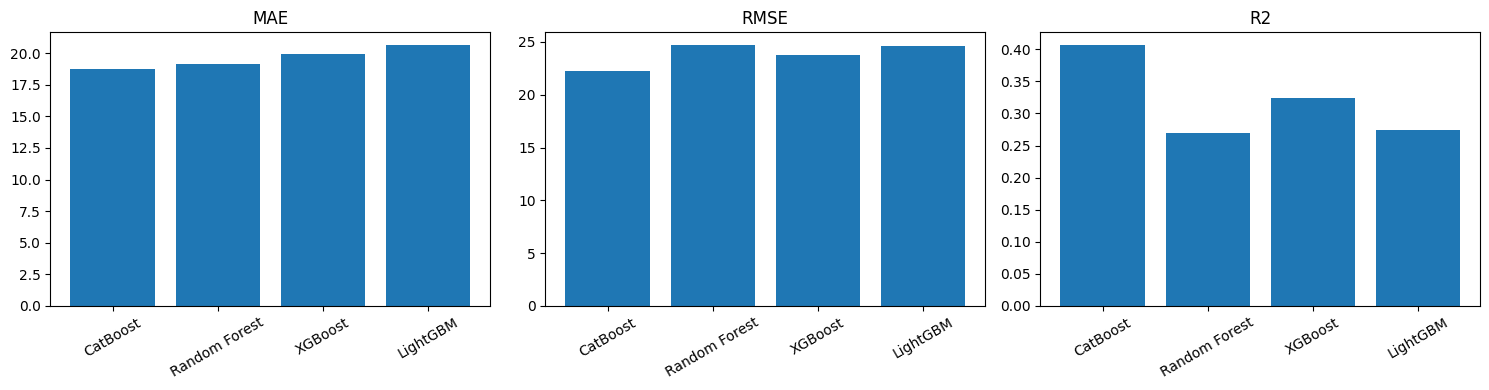

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    ax.bar(model_comparison["model"], model_comparison[metric])
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [13]:
best_model_name = model_comparison.iloc[0]["model"]
print(f"Best model from Section 6: {best_model_name} -- used for the ablation study below.")

model_constructors = {
    "Random Forest": lambda: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                                                     **best_params_clean["Random Forest"]),
    "XGBoost": lambda: xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0,
                                         **best_params_clean["XGBoost"]),
    "LightGBM": lambda: lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1,
                                           **best_params_clean["LightGBM"]),
    "CatBoost": lambda: cb.CatBoostRegressor(random_state=RANDOM_STATE, verbose=0,
                                              **best_params_clean["CatBoost"]),
}

ablation_records = []
for tier_name, tier_df in datasets.items():
    split = prepare_split(tier_df)
    model = model_constructors[best_model_name]()
    model.fit(split["X_train"], split["y_train"])
    preds = model.predict(split["X_test"])

    mae = mean_absolute_error(split["y_test"], preds)
    rmse = np.sqrt(mean_squared_error(split["y_test"], preds))
    r2 = r2_score(split["y_test"], preds)

    ablation_records.append({
        "feature_set": tier_name, "best_model": best_model_name,
        "n_features": len(split["feature_cols"]), "MAE": mae, "RMSE": rmse, "R2": r2,
    })
    print(f"{tier_name:15s} (n={len(split['feature_cols'])} feats)  "
          f"MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}")

ablation_results = pd.DataFrame(ablation_records)
ablation_path = os.path.join(OUTPUT_DIR, "ablation_results.csv")
ablation_results.to_csv(ablation_path, index=False)
print(f"\nSaved ablation results -> {ablation_path}")
ablation_results


Best model from Section 6: CatBoost -- used for the ablation study below.
time            (n=16 feats)  MAE=22.24  RMSE=25.71  R2=0.207
time_frequency  (n=30 feats)  MAE=18.45  RMSE=21.44  R2=0.448
all             (n=45 feats)  MAE=18.73  RMSE=22.24  R2=0.406

Saved ablation results -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/ablation_results.csv


,feature_set,best_model,n_features,MAE,RMSE,R2
0,time,CatBoost,16,22.238699,25.712782,0.206623
1,time_frequency,CatBoost,30,18.450980,21.441063,0.448337
2,all,CatBoost,45,18.727481,22.244893,0.406197


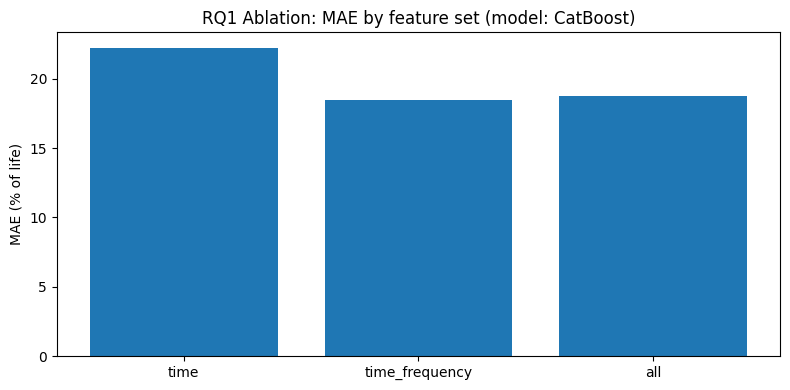


Honest read of the result (report whatever the numbers actually show, per project rule):
Adding frequency+wavelet features REDUCED MAE by 15.8% vs. time-domain only -> supports including them, answering RQ1 in the affirmative for this dataset/model.


In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ablation_results["feature_set"], ablation_results["MAE"])
ax.set_title(f"RQ1 Ablation: MAE by feature set (model: {best_model_name})")
ax.set_ylabel("MAE (% of life)")
plt.tight_layout()
plt.show()

print("\nHonest read of the result (report whatever the numbers actually show, per project rule):")
mae_time = ablation_results.loc[ablation_results.feature_set == "time", "MAE"].values[0]
mae_all = ablation_results.loc[ablation_results.feature_set == "all", "MAE"].values[0]
if mae_all < mae_time:
    improvement = (mae_time - mae_all) / mae_time * 100
    print(f"Adding frequency+wavelet features REDUCED MAE by {improvement:.1f}% vs. time-domain only "
          f"-> supports including them, answering RQ1 in the affirmative for this dataset/model.")
else:
    degradation = (mae_all - mae_time) / mae_time * 100
    print(f"Adding frequency+wavelet features INCREASED MAE by {degradation:.1f}% vs. time-domain only "
          f"-> on this run, richer features did not help; report this honestly rather than defaulting "
          f"to 'more features are better'. Consider: (a) re-running with FAST_DEMO=False for more "
          f"training data, (b) checking whether Section 10's redundancy filter over-pruned useful "
          f"frequency/wavelet features in the smaller tiers.")


In [15]:
best_row = ablation_results.sort_values("MAE").iloc[0]
final_feature_set = best_row["feature_set"]
final_model_name = best_row["best_model"]

print(f"Selected for Chapter 6: {final_model_name} trained on the '{final_feature_set}' feature set")
print(f"  MAE={best_row['MAE']:.2f}  RMSE={best_row['RMSE']:.2f}  R2={best_row['R2']:.3f}")

# Refit the selected model on the selected feature tier's full training data, for saving
final_split = prepare_split(datasets[final_feature_set])
final_model = model_constructors[final_model_name]()
final_model.fit(final_split["X_train"], final_split["y_train"])

model_path = os.path.join(OUTPUT_DIR, "best_model.pkl")
joblib.dump(final_model, model_path)
print(f"\nSaved best model -> {model_path}")

final_summary = {
    "selected_model": final_model_name,
    "selected_feature_set": final_feature_set,
    "n_features": int(best_row["n_features"]),
    "test_MAE": float(best_row["MAE"]),
    "test_RMSE": float(best_row["RMSE"]),
    "test_R2": float(best_row["R2"]),
    "hyperparameters": best_params_clean[final_model_name],
}
with open(os.path.join(OUTPUT_DIR, "best_model_parameters.json"), "w") as f:
    json.dump(final_summary, f, indent=2)

print("\nFinal selection summary:")
print(json.dumps(final_summary, indent=2))


Selected for Chapter 6: CatBoost trained on the 'time_frequency' feature set
  MAE=18.45  RMSE=21.44  R2=0.448

Saved best model -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/best_model.pkl

Final selection summary:
{
  "selected_model": "CatBoost",
  "selected_feature_set": "time_frequency",
  "n_features": 30,
  "test_MAE": 18.450979674113754,
  "test_RMSE": 21.44106270638703,
  "test_R2": 0.44833663847503447,
  "hyperparameters": {
    "learning_rate": 0.01,
    "iterations": 100,
    "depth": 6
  }
}


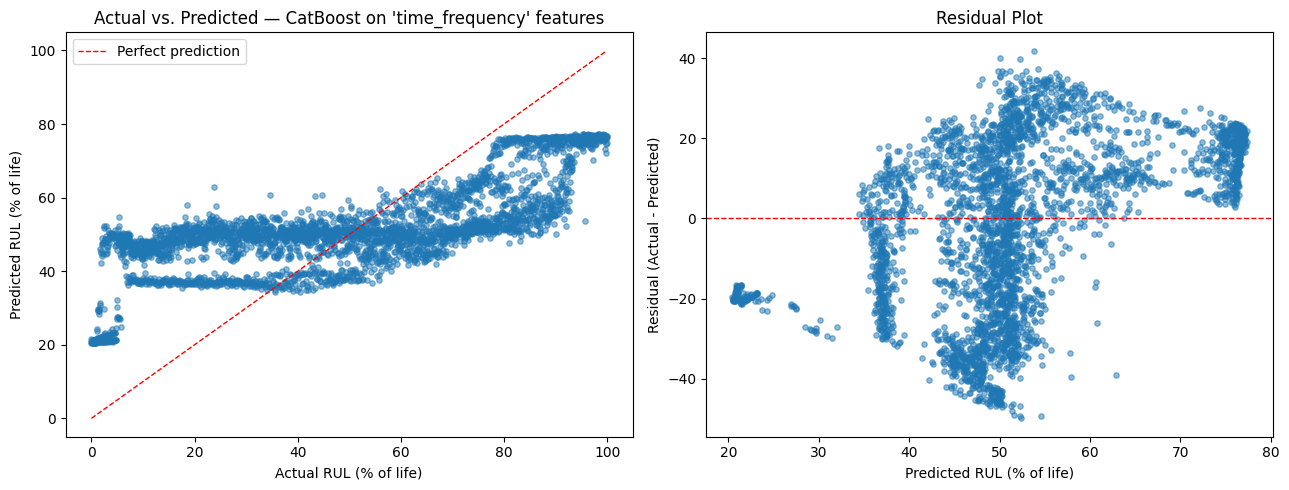

Residual mean: -1.83  (should be near 0 for an unbiased model)
Residual std : 21.36


In [16]:
final_preds = final_model.predict(final_split["X_test"])
final_actual = final_split["y_test"].values
final_residuals = final_actual - final_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(final_actual, final_preds, alpha=0.5, s=15)
lims = [min(final_actual.min(), final_preds.min()), max(final_actual.max(), final_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("Actual RUL (% of life)")
axes[0].set_ylabel("Predicted RUL (% of life)")
axes[0].set_title(f"Actual vs. Predicted — {final_model_name} on '{final_feature_set}' features")
axes[0].legend()

# Residuals
axes[1].scatter(final_preds, final_residuals, alpha=0.5, s=15)
axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[1].set_xlabel("Predicted RUL (% of life)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "prediction_diagnostics.png"), dpi=130)
plt.show()

print(f"Residual mean: {final_residuals.mean():.2f}  (should be near 0 for an unbiased model)")
print(f"Residual std : {final_residuals.std():.2f}")


In [17]:
test_predictions = final_split["test_df"][["bearing", "condition", "snapshot_idx",
                                            "total_life_snapshots", "RUL_snapshots"]].copy()
test_predictions["actual_RUL_pct"] = final_actual
test_predictions["predicted_RUL_pct"] = final_preds
test_predictions["residual_pct"] = final_residuals
# also express the prediction back in snapshot units, for readability alongside RUL_snapshots
test_predictions["predicted_RUL_snapshots"] = (
    test_predictions["predicted_RUL_pct"] / 100 * test_predictions["total_life_snapshots"]
).round().astype(int)

predictions_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
test_predictions.to_csv(predictions_path, index=False)
print(f"Saved test predictions -> {predictions_path}  {test_predictions.shape}")
test_predictions.head(10)


Saved test predictions -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/test_predictions.csv  (3305, 9)


,bearing,condition,snapshot_idx,total_life_snapshots,RUL_snapshots,actual_RUL_pct,predicted_RUL_pct,residual_pct,predicted_RUL_snapshots
0,Bearing1_2,Condition 1,1,871,870,99.885189,74.791506,25.093683,651
1,Bearing1_2,Condition 1,2,871,869,99.770379,76.643122,23.127257,668
2,Bearing1_2,Condition 1,3,871,868,99.655568,76.182195,23.473373,664
3,Bearing1_2,Condition 1,4,871,867,99.540758,76.500638,23.040120,666
4,Bearing1_2,Condition 1,5,871,866,99.425947,76.806064,22.619883,669
5,Bearing1_2,Condition 1,6,871,865,99.311137,76.746582,22.564554,668
6,Bearing1_2,Condition 1,7,871,864,99.196326,76.343681,22.852645,665
7,Bearing1_2,Condition 1,8,871,863,99.081515,75.908194,23.173322,661
8,Bearing1_2,Condition 1,9,871,862,98.966705,75.676696,23.290009,659
9,Bearing1_2,Condition 1,10,871,861,98.851894,75.756740,23.095154,660


In [18]:
model_path = os.path.join(OUTPUT_DIR, "best_model.pkl")
joblib.dump(final_model, model_path)
print(f"Saved model -> {model_path}")

Saved model -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/best_model.pkl


In [19]:
selected_feature_names_path = os.path.join(OUTPUT_DIR, "selected_feature_names.json")
with open(selected_feature_names_path, "w") as f:
    json.dump(final_split["feature_cols"], f, indent=2)
print(f"Saved selected feature names -> {selected_feature_names_path}")

Saved selected feature names -> /content/drive/MyDrive/FEMTO-ST/chapter5_outputs/selected_feature_names.json
